In [1]:
"""
@author: LC
"""

import numpy as np
import matplotlib.pyplot as plt


def kalman_filter2(z_prev, P_prev,A,H,Q,R,d): 
    # Kalman Filter function
    # without considering any input load
    # returns predicted and estimated quantities
    
    #prediction step
    z_pred = A@z_prev
    P_pred = A@P_prev@A.T + Q
    
    #Kalman Gain
    Kgain = P_pred @ H.T @ np.linalg.inv(H @ P_pred @ H.T + R)
    
    # estimation
    z_est = z_pred + Kgain @ (d - H@ z_pred)
    P_est = P_pred - Kgain @ H @ P_pred
    
    return z_pred, P_pred,z_est, P_est

def RTS_smoother(A,zp,zf,Pp,Pf,zs,Ps):
    # RTS smoother function
    
    Ks = Pf @ A.T @ np.linalg.inv(Pp) 
    zs_prev = zf + Ks @ (zs - zp)
    Ps_prev = Pf + Ks @ (Ps - Pp) @ Ks.T
    
    return zs_prev,Ps_prev


In [2]:
# =============================================================================
# Define state space matrices
# =============================================================================

# state transition matrix (computed elsewhere)
A = np.array([[ 9.87610634e-01,  7.42403599e-03,  9.88586175e-03, 5.39785161e-05],
              [ 7.42403599e-03,  9.92559992e-01,  5.39785161e-05, 9.92184743e-03],
              [-2.46336866e+00,  1.47478248e+00,  9.73143171e-01,1.32051843e-02],
              [ 1.47478248e+00, -1.48018034e+00,  1.32051843e-02,9.81946628e-01]])

#output matrix (computed elsewhere)
H = np.array([[ 150. , -150.  , 0.59064779, -1.07290968]])

#measurements (computed elsewhere)
d = np.loadtxt("measurement_KF_acc2.out").reshape(1,-1)

#measurements noise variance (computed elsewhere)
R = np.array([[1.157]]) # noise variance (assumed known)

#number of time steps
N = d.shape[1]

#number of states
n_states = len(A)

#Process noise covariance matrix
Q = 1e-15*np.eye(n_states) ##just something small



In [3]:


# =============================================================================
# Kalman Filter estimation
# =============================================================================
#initialize vector for estimation
z_kf = np.zeros([n_states,N])
zp_kf = np.zeros([n_states,N])
P_kf = np.zeros([n_states,n_states,N])
Pp_kf = np.zeros([n_states,n_states,N])


## initial state and error covariance
z0 = np.zeros(n_states)
P0 = np.eye(n_states) * 10  # 10 is relatively big compared to magnitude of displacements

#use P as error covariance without saving it.
P_kf[:,:,0] = P0



#KF loop
for k in range(1,N):
    zp_kf[:,k],Pp_kf[:,:,k],z_kf[:,k],P_kf[:,:,k] = kalman_filter2(z_kf[:,k-1], 
                                                                   P_kf[:,:,k-1], A, H, Q, R, 
                                                                   d[:,k])



#initialize RTS smoother quantities

zs = np.zeros_like(z_kf)
Ps = np.zeros_like(P_kf) 
zs[:,-1] = np.copy(z_kf[:,-1]) 
Ps[:,:,-1] = np.copy(P_kf[:,:,-1] )


#RTS smoother loop
for k in range(N-1,0,-1):    
    zs[:,k-1],Ps[:,:,k-1] = RTS_smoother(A,zp_kf[:,k],z_kf[:,k-1],
                                    Pp_kf[:,:,k],P_kf[:,:,k-1],
                                    zs[:,k],Ps[:,:,k])



#%% compare estimation with true response

import pickle

# Loading the array with the true responses (displacements and velocities)
with open('z_true.pkl', 'rb') as f:
    z_true = pickle.load(f)



dt = 0.01
t_end = dt*N
time_array = np.arange(N)*dt

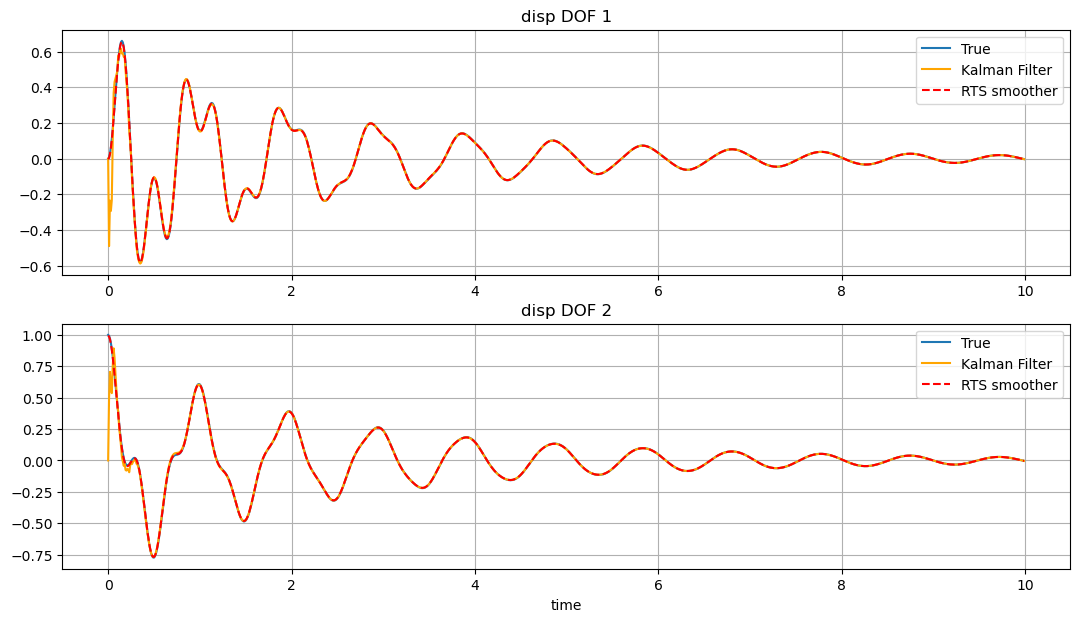

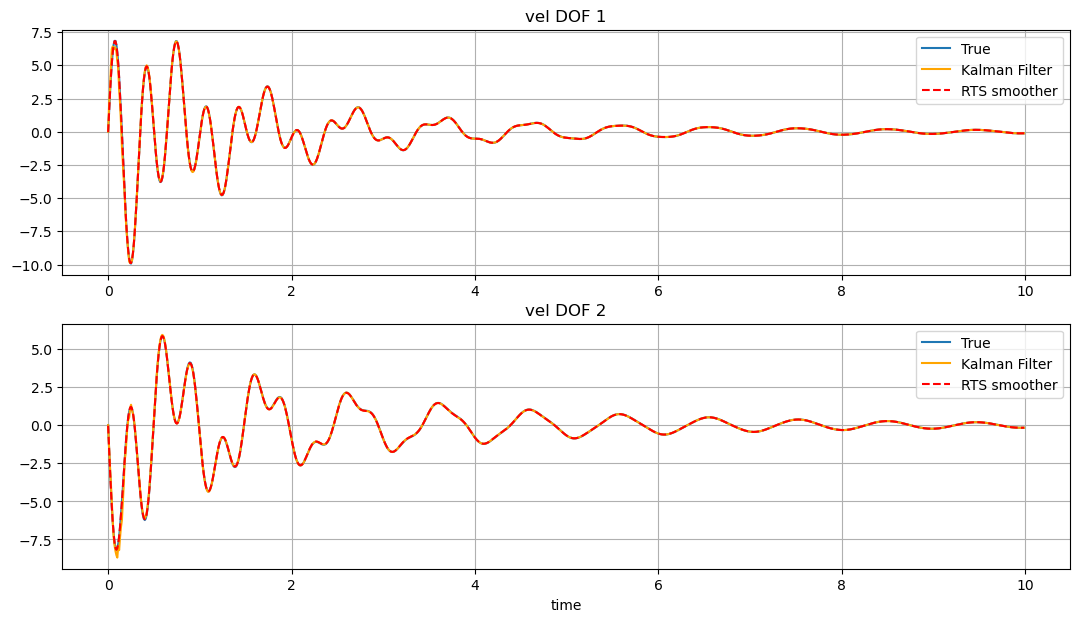

In [ ]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(13,7))
ax1.set_title("disp DOF 1")
ax2.set_title("disp DOF 2")

ax1.plot(time_array,z_true[0,:],label="True")
ax1.plot(time_array,z_kf[0,:],label="Kalman Filter",color="orange")
ax1.plot(time_array,zs[0,:],"--",label="RTS smoother",color="red")

ax2.plot(time_array,z_true[1,:],label="True")
ax2.plot(time_array,z_kf[1,:],label="Kalman Filter",color="orange")
ax2.plot(time_array,zs[1,:],"--",label="RTS smoother",color="red")

for ax in (ax1,ax2):
    ax.legend()
    ax.grid()

ax2.set_xlabel("time")
plt.show()

fig, (ax1,ax2) = plt.subplots(2,1,figsize=(13,7))
ax1.set_title("vel DOF 1")
ax2.set_title("vel DOF 2")

ax1.plot(time_array,z_true[2,:],label="True")
ax1.plot(time_array,z_kf[2,:],label="Kalman Filter",color="orange")
ax1.plot(time_array,zs[2,:],"--",label="RTS smoother",color="red")

ax2.plot(time_array,z_true[3,:],label="True")
ax2.plot(time_array,z_kf[3,:],label="Kalman Filter",color="orange")
ax2.plot(time_array,zs[3,:],"--",label="RTS smoother",color="red")

for ax in (ax1,ax2):
    ax.legend()
    ax.grid()

ax2.set_xlabel("time")
plt.show()